# Разведочный анализ данных (EDA)

**Проект:** Рекомендации по замене блюд

**Цель этапа:** изучить датасет, понять структуру и распределение признаков, выявить закономерности, которые пригодятся для дальнейшей разметки данных и построения моделей.

**Датасет:** Daily Food & Nutrition Dataset (Kaggle)

## 1. Импорт библиотек

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Настройка отображения таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 2. Загрузка данных

В исходном CSV-файле обнаружена проблема: в некоторых названиях блюд встречаются запятые (например, `Milk (2%, 1 cup)`), а сам текст не был взят в кавычки в исходном файле. Из-за этого стандартный парсер CSV неправильно разбивает такие строки на столбцы.

Ниже функция, которая читает файл построчно и аккуратно склеивает разбитые поля обратно.

In [13]:
import csv

def load_and_fix_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        n_cols = len(header)
        fixed_rows = []
        for row in reader:
            if len(row) == n_cols:
                fixed_rows.append(row)
            elif len(row) == n_cols + 1:
                # Запятая внутри названия блюда разбила одно поле на два — склеиваем обратно
                new_row = [row[0] + ',' + row[1]] + row[2:]
                fixed_rows.append(new_row)
            else:
                print('Неожиданная строка, пропущена:', row)
    return pd.DataFrame(fixed_rows, columns=header)

df = load_and_fix_csv('../data/daily_food_nutrition.csv')

# Приводим числовые столбцы к нужному типу (после ручного парсинга все столбцы — строки)
numeric_cols = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)',
                 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Water_Intake (ml)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

print('Размер таблицы:', df.shape)
df.head()

Размер таблицы: (651, 13)


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),Category_Grouped
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250,Protein
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0,Grain
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0,Beverage
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0,Fruit
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500,Meal


## 3. Группировка категорий

Признак `Category` содержит много узких подкатегорий (например, `Meal/Legume`, `Meal/Fish`), часть из которых встречается всего 1-3 раза в датасете. Такие редкие категории мешают модели обучаться — она не может найти закономерность по 1-2 примерам.

Решение: оставляем только основную часть категории (до символа `/`).

In [14]:
df['Category_Grouped'] = df['Category'].apply(lambda x: x.split('/')[0])

print('Было уникальных категорий:', df['Category'].nunique())
print('Стало уникальных категорий:', df['Category_Grouped'].nunique())
print()
df['Category_Grouped'].value_counts()

Было уникальных категорий: 46
Стало уникальных категорий: 13



Category_Grouped
Condiment     129
Meal          116
Vegetable      76
Grain          69
Beverage       64
Protein        60
Fruit          34
Dairy          29
Dessert        27
Snack          20
Nut            14
Legume         11
Supplement      2
Name: count, dtype: int64

## 4. Общая информация о датасете

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Food_Item          651 non-null    str    
 1   Category           651 non-null    str    
 2   Calories (kcal)    651 non-null    int64  
 3   Protein (g)        651 non-null    float64
 4   Carbohydrates (g)  651 non-null    float64
 5   Fat (g)            651 non-null    float64
 6   Fiber (g)          651 non-null    float64
 7   Sugars (g)         651 non-null    float64
 8   Sodium (mg)        651 non-null    int64  
 9   Cholesterol (mg)   651 non-null    int64  
 10  Meal_Type          651 non-null    str    
 11  Water_Intake (ml)  651 non-null    int64  
 12  Category_Grouped   651 non-null    str    
dtypes: float64(5), int64(4), str(4)
memory usage: 66.2 KB


In [16]:
print('Пропуски по столбцам:')
df.isnull().sum()

Пропуски по столбцам:


Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
Category_Grouped     0
dtype: int64

**Вывод:** пропущенных значений в данных нет

In [17]:
df.describe()

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Water_Intake (ml)
count,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000,651.000000
mean,145.494624,6.257911,15.351459,6.418587,1.688786,5.299386,244.508449,20.324117,68.635945
std,139.771323,8.757554,16.311885,8.124418,2.116408,8.526541,307.682970,43.395473,136.749207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.500000,1.200000,0.200000,0.000000,0.400000,5.000000,0.000000,0.000000
50%,105.000000,2.700000,9.000000,3.000000,1.000000,2.000000,120.000000,0.000000,0.000000
75%,200.000000,7.000000,26.000000,10.000000,3.000000,6.000000,350.000000,25.000000,0.000000
max,680.000000,45.000000,70.000000,40.000000,14.000000,60.000000,1580.000000,450.000000,500.000000


## 5. Распределение ключевых числовых признаков

Рассмотрим, как распределены ключевые показатели: калории, сахар, клетчатка, натрий и холестерин - это понадобится позже при определении правил разметки "нужна ли замена блюду".

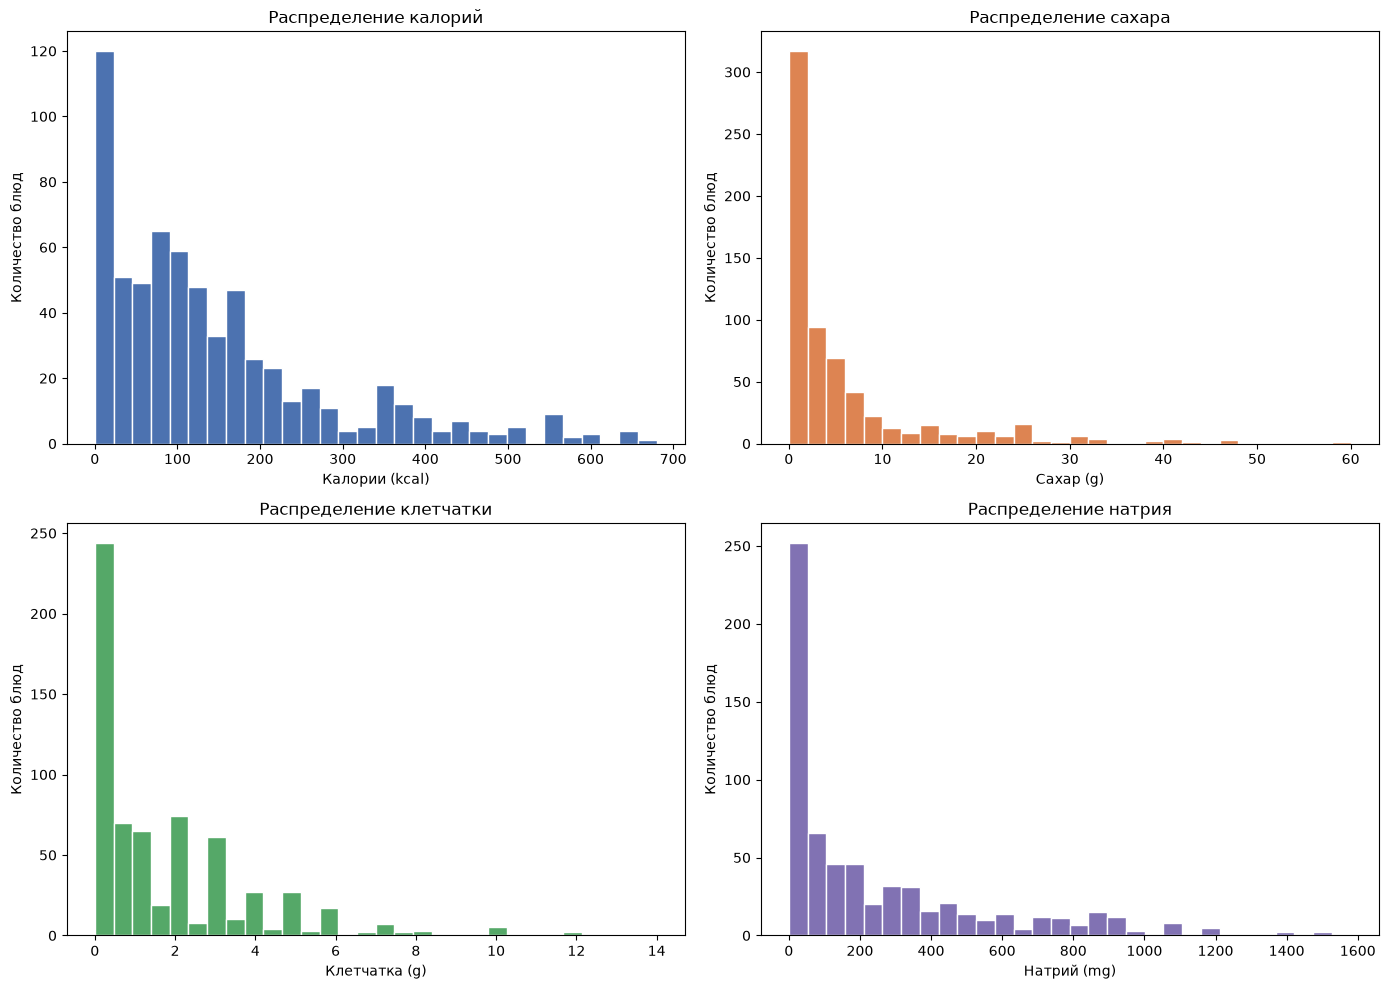

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['Calories (kcal)'], bins=30, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Распределение калорий')
axes[0,0].set_xlabel('Калории (kcal)')
axes[0,0].set_ylabel('Количество блюд')

axes[0,1].hist(df['Sugars (g)'], bins=30, color='#DD8452', edgecolor='white')
axes[0,1].set_title('Распределение сахара')
axes[0,1].set_xlabel('Сахар (g)')
axes[0,1].set_ylabel('Количество блюд')

axes[1,0].hist(df['Fiber (g)'], bins=30, color='#55A868', edgecolor='white')
axes[1,0].set_title('Распределение клетчатки')
axes[1,0].set_xlabel('Клетчатка (g)')
axes[1,0].set_ylabel('Количество блюд')

axes[1,1].hist(df['Sodium (mg)'], bins=30, color='#8172B3', edgecolor='white')
axes[1,1].set_title('Распределение натрия')
axes[1,1].set_xlabel('Натрий (mg)')
axes[1,1].set_ylabel('Количество блюд')

plt.tight_layout()
plt.show()

**Вывод:** все четыре признака имеют скошенное вправо распределение - большинство блюд имеют низкие значения, а небольшая часть блюд (с высокой калорийностью, сахаром и т.д.) образует "длинный хвост" справа. Это важно учитывать: для таких распределений медиана - более надёжная характеристика "типичного" значения, чем среднее, так как среднее сильно искажается редкими выбросами.

## 6. Калорийность по типу приёма пищи и категории

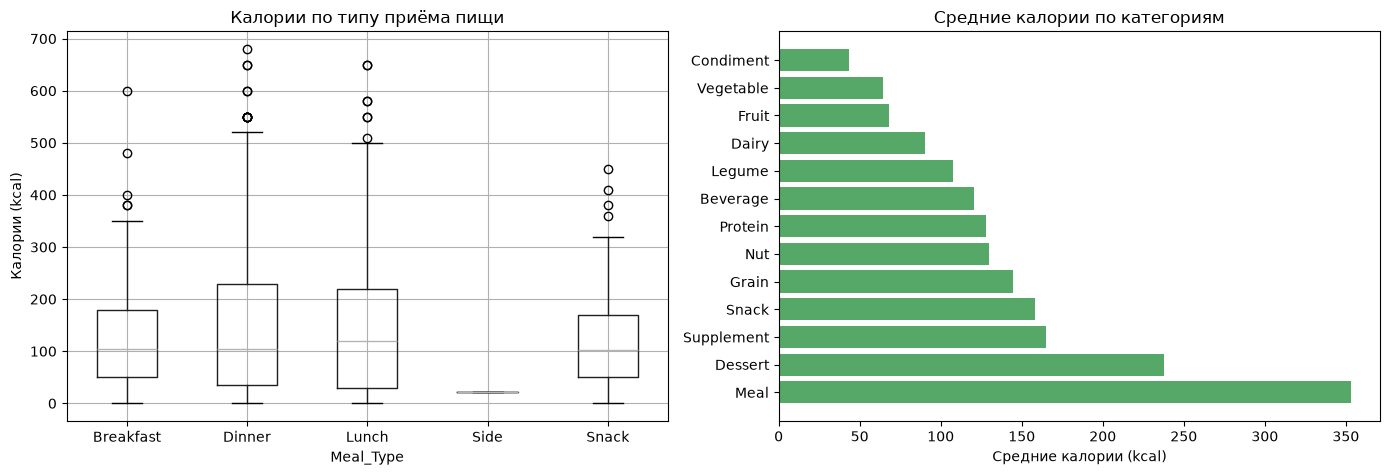

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Calories (kcal)', by='Meal_Type', ax=axes[0])
axes[0].set_title('Калории по типу приёма пищи')
axes[0].set_xlabel('Meal_Type')
axes[0].set_ylabel('Калории (kcal)')
plt.suptitle('')

cat_means = df.groupby('Category_Grouped')['Calories (kcal)'].mean().sort_values(ascending=False)
axes[1].barh(cat_means.index, cat_means.values, color='#55A868')
axes[1].set_title('Средние калории по категориям')
axes[1].set_xlabel('Средние калории (kcal)')

plt.tight_layout()
plt.show()

**Вывод:** категория блюда хорошо различает калорийность — `Meal` (полноценные блюда) и `Dessert` (десерты) в среднем самые калорийные, а `Condiment` (приправы) и `Vegetable` (овощи) — наименее калорийные. Это говорит о том, что признак `Category_Grouped` несёт полезную информацию для модели.

По типу приёма пищи медианные значения калорий похожи между Breakfast, Lunch, Dinner и Snack, но разброс (межквартильный размах) у Lunch и Dinner заметно больше — там встречаются как лёгкие, так и тяжёлые блюда.

## 7. Корреляция числовых признаков

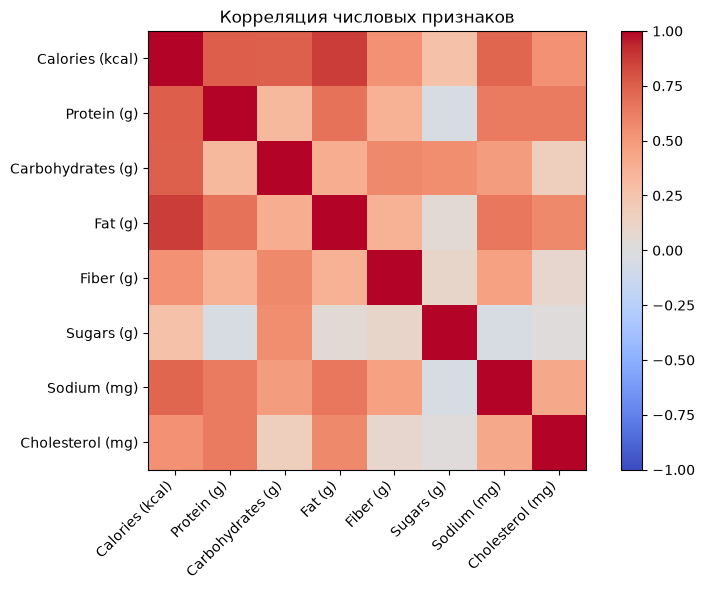

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg)
Calories (kcal),1.000000,0.755254,0.745266,0.869051,0.531824,0.267370,0.719926,0.538533
Protein (g),0.755254,1.000000,0.325089,0.675658,0.369274,-0.044234,0.634356,0.635988
Carbohydrates (g),0.745266,0.325089,1.000000,0.396033,0.575997,0.547016,0.479175,0.158521
Fat (g),0.869051,0.675658,0.396033,1.000000,0.370116,0.042362,0.649998,0.574643
Fiber (g),0.531824,0.369274,0.575997,0.370116,1.000000,0.098726,0.455510,0.080579
Sugars (g),0.267370,-0.044234,0.547016,0.042362,0.098726,1.000000,-0.046340,0.008488
Sodium (mg),0.719926,0.634356,0.479175,0.649998,0.455510,-0.046340,1.000000,0.417182
Cholesterol (mg),0.538533,0.635988,0.158521,0.574643,0.080579,0.008488,0.417182,1.000000


In [20]:
num_cols = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)',
            'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)
plt.colorbar(im, fraction=0.046)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

corr

**Вывод:** калории, белки, углеводы и жиры положительно коррелируют друг с другом — логично, ведь более "плотные" по составу блюда обычно содержат больше всего сразу. При этом сахар (`Sugars`) почти не коррелирует с остальными признаками — это независимый сигнал, который имеет смысл учитывать отдельно при разметке данных, а не как дублирующий калории показатель.

Холестерин у 75% блюд равен нулю (это видно из таблицы `describe()` выше) — присутствует в основном в продуктах животного происхождения, поэтому медиана для этого признака неинформативна и для ручных правил разметки его лучше не использовать.

## 8. Общие выводы по EDA

1. Датасет содержит 651 блюдо, 12 исходных признаков, пропущенных значений нет.
2. В исходном файле было 6 строк с технической ошибкой (запятая в названии блюда без кавычек) — ошибка исправлена при загрузке.
3. Признак `Category` сгруппирован с 47 до 13 крупных категорий для уменьшения количества редких значений.
4. Калории, сахар, клетчатка и натрий имеют скошенное распределение — при дальнейшей разметке данных предпочтительнее использовать медиану/квантили, а не среднее значение.
5. Категория и тип приёма пищи логично связаны с калорийностью блюд — эти признаки полезны для модели.
6. Сахар — независимый от калорий признак, холестерин малоинформативен из-за большого количества нулевых значений.

Эти выводы будут использованы на следующем этапе - создании целевой переменной (правил, по которым определяется, нужна ли блюду замена).